In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from anngeno import AnnGeno
# pl.Config.set_tbl_rows(15)

/home/dnanexus/anngeno/anngeno/anngeno.py:14: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [62]:
# Configuration and paths
or_threshold_pheno = 0.99
or_threshold_anno = 0.99

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)

config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)


# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""plof""","""loftee_hc""","""#1f77b4""","""LOFTEE HC""",1
"""missense""","""am_pathogenicity""","""#feb72d""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""conservation""","""gpn_star_llr_calibrated_mean""","""#942c80""","""GPN-Star""",-1
…,…,…,…,…
"""splicing""","""absplice_dna_max""","""#28a745""","""AbSplice (max)""",1
"""splicing""","""absplice2_max""","""#28a745""","""AbSplice2 (max)""",1
"""regulatory_nondir""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",1


In [32]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_variants_union_annotated_250928.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
# existing_annos += ['five_prime_utr_variant_consequence_uaug_gained', 'five_prime_utr_variant_consequence_uaug_lost', 'five_prime_utr_variant_consequence_uframeshift', 'five_prime_utr_variant_consequence_ustop_gained', 'five_prime_utr_variant_consequence_ustop_lost']

existing_annos = ['cadd_raw', 'gpn_score', 'gpn_star_llr_calibrated_mean']

# Filter variant classes
variant_class = "intronic"
consequences_for_group = var_cons.filter(
    pl.col('variant_class') == variant_class
)['vep_consequence'].to_list()
filter_expression = pl.any_horizontal(
    (pl.col(c) == 1) for c in consequences_for_group if c in anno.collect_schema().names()
)

min_range = -2000
max_range = +0

anno = (
    anno
    .filter(
        filter_expression &
        # (pl.col('consequence_splice_acceptor_variant') == 0) & (pl.col('consequence_splice_donor_variant') == 0) &
        # (pl.col('consequence_splice_acceptor_variant') == 1) | (pl.col('consequence_splice_donor_variant') == 1) &
        # (pl.col('dist_to_tss') >= min_range) &
        # (pl.col('dist_to_tss') <= max_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

gpn_star_llr_calibrated_mean,gene_length,gpn_score,Strand,TSS,region,dist_to_tss,gene_name,cadd_raw,id
f64,i64,f32,cat,i64,str,i64,str,f32,str
0.153293,235427,-1.5,"""-""",169362534,"""ENSG00000081479""",165367,"""LRP2""",0.466688,"""chr2:169197167:T:G"""
1.684965,235427,-0.63,"""-""",169362534,"""ENSG00000081479""",158242,"""LRP2""",0.104863,"""chr2:169204292:A:T"""
-1.212965,115828,-1.64,"""-""",169031324,"""ENSG00000073734""",793,"""ABCB11""",0.326902,"""chr2:169030531:C:T"""
-0.238119,115828,0.08,"""-""",169031324,"""ENSG00000073734""",24150,"""ABCB11""",-0.070862,"""chr2:169007174:C:T"""
-1.768037,235427,-0.98,"""-""",169362534,"""ENSG00000081479""",186782,"""LRP2""",0.211538,"""chr2:169175752:G:A"""
…,…,…,…,…,…,…,…,…,…
0.631638,30467,1.12,"""+""",112332346,"""ENSG00000091972""",33086,"""CD200""",-0.577349,"""chr3:112365432:T:C"""
0.406711,30467,-4.13,"""+""",112332346,"""ENSG00000091972""",-2257,"""CD200""",0.73253,"""chr3:112330089:T:G"""
-1.380881,30467,-1.89,"""+""",112332346,"""ENSG00000091972""",-3020,"""CD200""",0.636473,"""chr3:112329326:T:C"""


In [33]:
melted_anno = (
    anno.unpivot(
        index=["id", "region"],
        on=existing_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df,
        on="annotation",
        how="left"
    )
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir")
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_rank = pl.col('annotation_score_dircor').rank(method="average").over(["region", "annotation"]),
        anno_score_count = pl.len().over(["region", "annotation"])
    )
    .with_columns(
        annotation_score_dircor_ptile = pl.col('annotation_score_dircor_rank') / pl.col('anno_score_count')
    )
    .filter(
        pl.col('annotation_score_dircor_ptile') > or_threshold_anno
    )
)

melted_anno

id,region,annotation,annotation_score,category,color,label,annotation_dir,annotation_score_dircor,annotation_score_dircor_rank,anno_score_count,annotation_score_dircor_ptile
str,str,str,f32,str,str,str,i64,f64,f64,u64,f64
"""chr2:168983350:T:A""","""ENSG00000073734""","""cadd_raw""",1.59653,"""genetic_diversity""","""#AA4344""","""CADD Raw""",1,1.59653,36403.0,36675,0.992584
"""chr2:213104762:T:G""","""ENSG00000030419""","""cadd_raw""",2.790495,"""genetic_diversity""","""#AA4344""","""CADD Raw""",1,2.790495,47538.0,47956,0.991284
"""chr2:213056612:C:A""","""ENSG00000030419""","""cadd_raw""",2.999623,"""genetic_diversity""","""#AA4344""","""CADD Raw""",1,2.999623,47724.0,47956,0.995162
"""chr2:212535987:C:T""","""ENSG00000178568""","""cadd_raw""",2.477477,"""genetic_diversity""","""#AA4344""","""CADD Raw""",1,2.477477,426890.0,430225,0.992248
"""chr2:168985969:T:C""","""ENSG00000073734""","""cadd_raw""",2.775712,"""genetic_diversity""","""#AA4344""","""CADD Raw""",1,2.775712,36653.0,36675,0.9994
…,…,…,…,…,…,…,…,…,…,…,…
"""chr3:79769402:C:G""","""ENSG00000169855""","""gpn_star_llr_calibrated_mean""",-5.806743,"""conservation""","""#942c80""","""GPN-Star""",-1,5.806743,424354.0,426185,0.995704
"""chr3:74544005:T:G""","""ENSG00000113805""","""gpn_star_llr_calibrated_mean""",-4.212284,"""conservation""","""#942c80""","""GPN-Star""",-1,4.212284,129362.0,130662,0.990051
"""chr1:247375971:A:G""","""ENSG00000162711""","""gpn_star_llr_calibrated_mean""",-2.982644,"""conservation""","""#942c80""","""GPN-Star""",-1,2.982644,37765.0,38098,0.991259


In [34]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = appv.join(
    anno_keys, on='id', how='semi'
).filter(
    pl.col('n_individuals') <= mac
)

# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

In [35]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)

# gene_trait_df = gene_trait_df.head()
gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


In [36]:
gene_trait_df['region'].n_unique(), gene_trait_df.shape[0]

(352, 1176)

In [68]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- Build main query (same as before, but stop before group_by) ---
gp_lazy = (
    appv
    .join(anno_ids_lazy, on="id", how="semi")
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]), 
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor = pl.col('mean_pheno_value') * pl.col('loftee_corr')
    )
    .with_columns(
        mean_pheno_value_dircor_rank = pl.col('mean_pheno_value_dircor').rank(method="average").over(["region", "annotation"]),
        mean_pheno_value_count = pl.len().over(["region", "annotation"])
    )
    .with_columns(
        mean_pheno_value_dircor_ptile = pl.col('mean_pheno_value_dircor_rank') / pl.col('mean_pheno_value_count')
    )
)

# Create a lazy dataframe of cutoffs
cutoffs_lazy = pl.LazyFrame({
    # scale from or_threshold_anno to 1.0
    "ptile_cutoff": [or_threshold_anno + (i*(1-or_threshold_anno))/100 for i in range(100)]
})

# Cross join with cutoffs and compute odds ratios
or_lazy = (
    gp_lazy
    .select(["annotation", "region", "gene_name", "phenotype", "annotation_score_dircor_ptile", "mean_pheno_value_dircor_ptile"])
    .join(cutoffs_lazy, how="cross")
    .with_columns(
        above_cutoff = pl.col("annotation_score_dircor_ptile") >= pl.col("ptile_cutoff")
    )
    .group_by(["annotation", "region", "gene_name", "phenotype", "ptile_cutoff"])
    .agg(
        n_dis_above_cutoff = (pl.col("above_cutoff") &(pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)).sum(),
        n_notdis_above_cutoff = (pl.col("above_cutoff") & (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)).sum()
    )
    .with_columns(
        odds_ratio = ((pl.col("n_dis_above_cutoff") + 1) / (pl.col("n_notdis_above_cutoff")+1)) / (1 - or_threshold_pheno)
    )
)

# Execute
print("Executing with odds ratios...")
or_df = or_lazy.collect(engine='streaming').sort('ptile_cutoff')
or_df

Executing with odds ratios...


annotation,region,gene_name,phenotype,ptile_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,odds_ratio
str,str,str,str,f64,u64,u64,f64
"""gpn_star_llr_calibrated_mean""","""ENSG00000138688""","""KIAA1109""","""leg_fat_mass_left_int""",0.99,2,383,0.78125
"""gpn_star_llr_calibrated_mean""","""ENSG00000131183""","""SLC34A1""","""creatinine_int""",0.99,0,31,3.125
"""gpn_star_llr_calibrated_mean""","""ENSG00000151914""","""DST""","""forced_expiratory_volume_in_1s…",0.99,19,882,2.265006
"""gpn_star_llr_calibrated_mean""","""ENSG00000164631""","""ZNF12""","""igf1_int""",0.99,1,26,7.407407
"""gpn_star_llr_calibrated_mean""","""ENSG00000196739""","""COL27A1""","""leg_fatfree_mass_left_int""",0.99,1,281,0.70922
…,…,…,…,…,…,…,…
"""gpn_score""","""ENSG00000087237""","""CETP""","""apolipoprotein_a_int""",0.9999,0,1,50.0
"""gpn_star_llr_calibrated_mean""","""ENSG00000004939""","""SLC4A1""","""cholesterol_int""",0.9999,0,1,50.0
"""cadd_raw""","""ENSG00000101745""","""ANKRD12""","""fluid_intelligence_score_int""",0.9999,0,1,50.0


In [69]:
or_df

annotation,region,gene_name,phenotype,ptile_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,odds_ratio
str,str,str,str,f64,u64,u64,f64
"""gpn_star_llr_calibrated_mean""","""ENSG00000138688""","""KIAA1109""","""leg_fat_mass_left_int""",0.99,2,383,0.78125
"""gpn_star_llr_calibrated_mean""","""ENSG00000131183""","""SLC34A1""","""creatinine_int""",0.99,0,31,3.125
"""gpn_star_llr_calibrated_mean""","""ENSG00000151914""","""DST""","""forced_expiratory_volume_in_1s…",0.99,19,882,2.265006
"""gpn_star_llr_calibrated_mean""","""ENSG00000164631""","""ZNF12""","""igf1_int""",0.99,1,26,7.407407
"""gpn_star_llr_calibrated_mean""","""ENSG00000196739""","""COL27A1""","""leg_fatfree_mass_left_int""",0.99,1,281,0.70922
…,…,…,…,…,…,…,…
"""gpn_score""","""ENSG00000087237""","""CETP""","""apolipoprotein_a_int""",0.9999,0,1,50.0
"""gpn_star_llr_calibrated_mean""","""ENSG00000004939""","""SLC4A1""","""cholesterol_int""",0.9999,0,1,50.0
"""cadd_raw""","""ENSG00000101745""","""ANKRD12""","""fluid_intelligence_score_int""",0.9999,0,1,50.0


In [70]:
plt_df = (
    or_df
    .drop_nans()
    .with_columns(
        avg_odds_ratio = pl.col('odds_ratio').mean().over(['ptile_cutoff', 'annotation']),
        std_odds_ratio = pl.col('odds_ratio').std().over(['ptile_cutoff', 'annotation']),
    )
    .with_columns(
        std_ci_upper = pl.col('avg_odds_ratio') + 1.96 * (pl.col('std_odds_ratio')),
        std_ci_lower = pl.col('avg_odds_ratio') - 1.96 * (pl.col('std_odds_ratio')),
    )
    .select(['annotation', 'ptile_cutoff', 'avg_odds_ratio', 'std_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .unique()
    .join(
        anno_config_df.select(['annotation', 'color', 'label']),
        on='annotation',
        how='left'
    )
    .sort('ptile_cutoff')
)
plt_df

annotation,ptile_cutoff,avg_odds_ratio,std_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,f64,f64,f64,f64,str,str
"""gpn_score""",0.99,5.652828,14.039347,33.169948,-21.864292,"""#942c80""","""GPN-MSA"""
"""gpn_star_llr_calibrated_mean""",0.99,5.780414,14.431701,34.066548,-22.505721,"""#942c80""","""GPN-Star"""
"""cadd_raw""",0.99,5.52934,14.031902,33.031867,-21.973188,"""#1f77b4""","""CADD Raw"""
"""cadd_raw""",0.9901,5.537767,14.024386,33.025564,-21.950029,"""#1f77b4""","""CADD Raw"""
"""gpn_star_llr_calibrated_mean""",0.9901,5.789401,14.432977,34.078035,-22.499233,"""#942c80""","""GPN-Star"""
…,…,…,…,…,…,…,…
"""gpn_score""",0.9998,40.033308,32.539059,103.809863,-23.743246,"""#942c80""","""GPN-MSA"""
"""cadd_raw""",0.9998,36.406149,30.503566,96.193139,-23.380841,"""#1f77b4""","""CADD Raw"""
"""cadd_raw""",0.9999,47.350802,31.75709,109.594699,-14.893095,"""#1f77b4""","""CADD Raw"""


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/guides/guides.py:211: PlotnineWarning: Cannot generate legend for the 'fill' aesthetic. Make sure you have mapped a variable to it


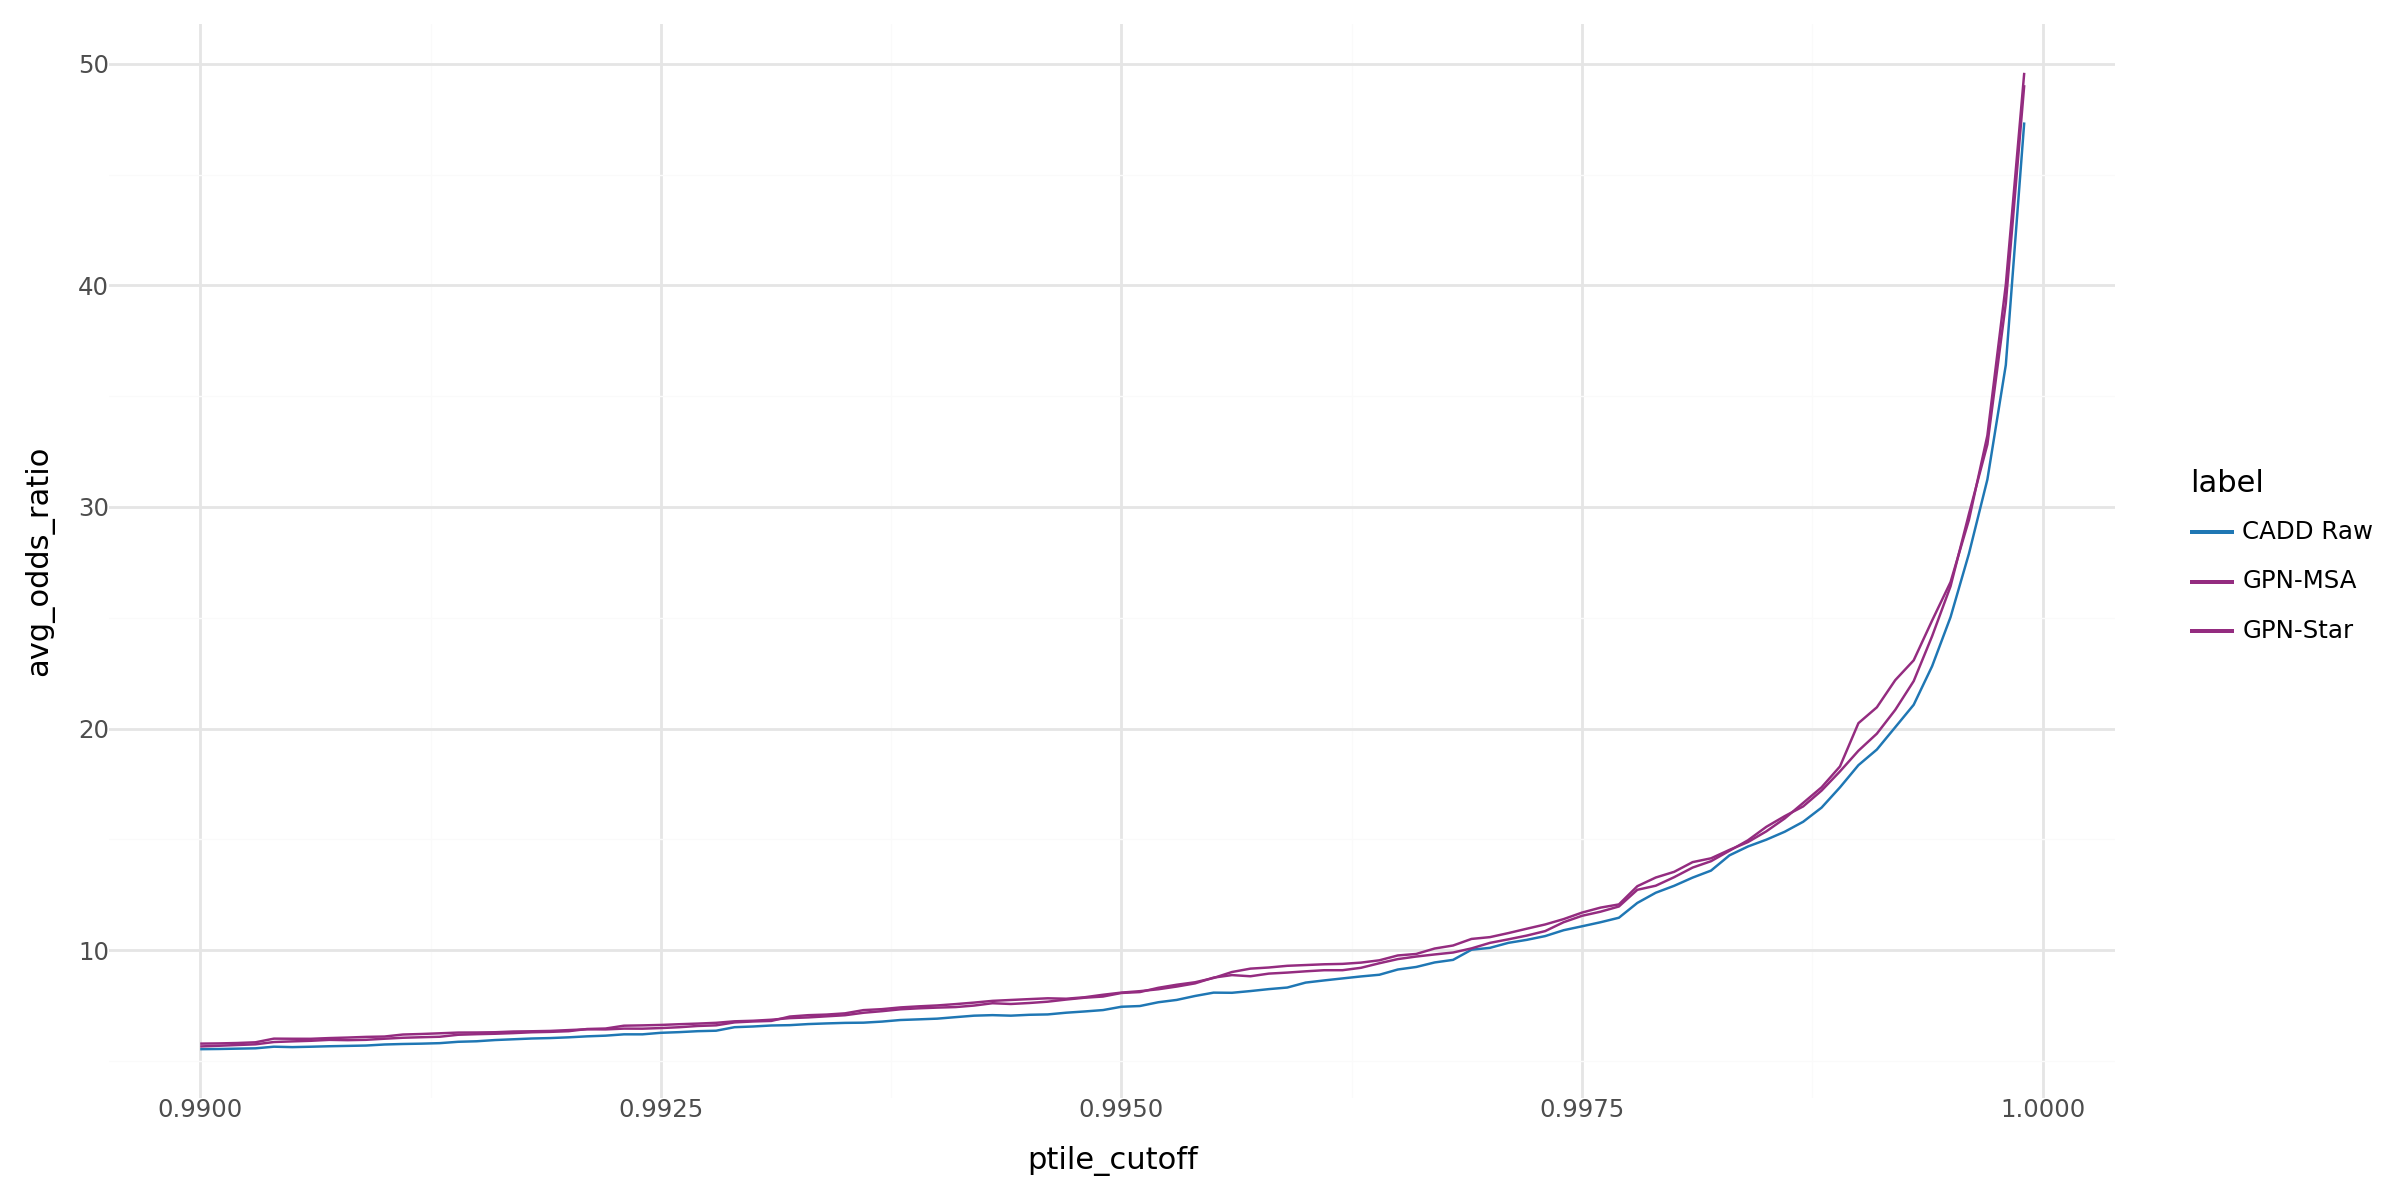

In [71]:
color_dict = dict(zip(plt_df['label'], plt_df['color']))

(
    ggplot(
        plt_df,
        aes(x='ptile_cutoff', y='avg_odds_ratio', color='label')
    )
    + geom_line()
    # + geom_ribbon(aes(ymin='std_ci_lower', ymax='std_ci_upper', fill='label'), alpha=0.2)
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + theme_minimal()
    + theme(figure_size=(12, 6))
)